In [1]:
%matplotlib inline

# Age Structure

* **Input**: cleaned and optimized pickeled DataFrames (persons.csv) for 20XX, BSF age predictions
* **Output**: Visualisations

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Settings" data-toc-modified-id="Settings-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Settings</a></span></li><li><span><a href="#Loading-Data" data-toc-modified-id="Loading-Data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Loading Data</a></span><ul class="toc-item"><li><span><a href="#SynPop" data-toc-modified-id="SynPop-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>SynPop</a></span></li><li><span><a href="#FSO-Predictions-(only-permanent-residents)" data-toc-modified-id="FSO-Predictions-(only-permanent-residents)-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>FSO Predictions (only permanent residents)</a></span></li></ul></li><li><span><a href="#Analysis" data-toc-modified-id="Analysis-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Analysis</a></span><ul class="toc-item"><li><span><a href="#BLS---SynPop-Comparison" data-toc-modified-id="BLS---SynPop-Comparison-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>BLS - SynPop Comparison</a></span></li></ul></li><li><span><a href="#Export-Notebook-to-HTML" data-toc-modified-id="Export-Notebook-to-HTML-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Export Notebook to HTML</a></span></li></ul></div>

In [2]:
import logging
import os
import sys
import pandas as pd

from matplotlib import pyplot as plt

In [3]:
sys.path.append(r'X:\90_Persoenlich\u229285\dev\SynPopToolbox')

In [4]:
from synpop.marginals import FSO_PopPredictionsClient
import synpop.utils as utils

## Settings

In [5]:
YEAR = 2030

DATA_DIR = r'\\k13536\mobi\10_Daten\SynPop\2030\02_preprocessed'
SYNPOP_PERSONS_FILE = os.path.join(DATA_DIR, 'persons_{}.pickle.gzip'.format(YEAR))

**Plot Export Settings**

In [6]:
SAVE_FIGURES = True
OUTPUT_DIR = './outputs'
FIG_FORMAT = 'png'
FIG_DPI = 150
FIG_BBOX_INCHES = 'tight'
FIG_PAD_INCHES = 0.2

In [7]:
utils.create_dir(OUTPUT_DIR)

2020-02-18 10:06:08,623 - INFO - synpop.utils: "./outputs" exists already


## Loading Data

### SynPop

In [8]:
SYNPOP_PERSONS_FILE

'\\\\k13536\\mobi\\10_Daten\\SynPop\\2030\\02_preprocessed\\persons_2030.pickle.gzip'

In [9]:
%%time
persons = pd.read_pickle(SYNPOP_PERSONS_FILE, compression='gzip') 

Wall time: 15.1 s


In [10]:
persons.shape

(9557232, 33)

In [11]:
persons['age_group'] = utils.bin_variable(persons['age'], interval_size=5, max_regular_intervals=100, last_bin_name='100-120')

In [12]:
synpop_stats = (persons.groupby('age_group')['person_id'].count()
                       .rename('SynPop')
                      )

### FSO Predictions (only permanent residents) 

In [13]:
fso_client = FSO_PopPredictionsClient().load(year=YEAR)

In [14]:
bfs_stats = fso_client.pop_by_age_group.set_index('age_group')['pop'].rename('BFS')

## Analysis 

### BLS - SynPop Comparison

In [15]:
pop_per_age_group = (pd.concat([bfs_stats, synpop_stats], axis=1)
                     .fillna(0)
                     .astype(int)
                     .loc[bfs_stats.index]  # Order age groups correctly 
                    )

In [16]:
pop_per_age_group

,BFS,SynPop
age_group,,
0-4,370365,465573
5-9,472761,477965
10-14,470409,473604
15-19,462548,466523
20-24,470990,480620
25-29,508421,521757
30-34,592495,608145
35-39,655167,664586
40-44,680335,686783


2020-02-18 10:06:36,734 - INFO - root: Figure saved to file : ./outputs\03-01_SynPop2030_vs_BFS_global_age_structure.png


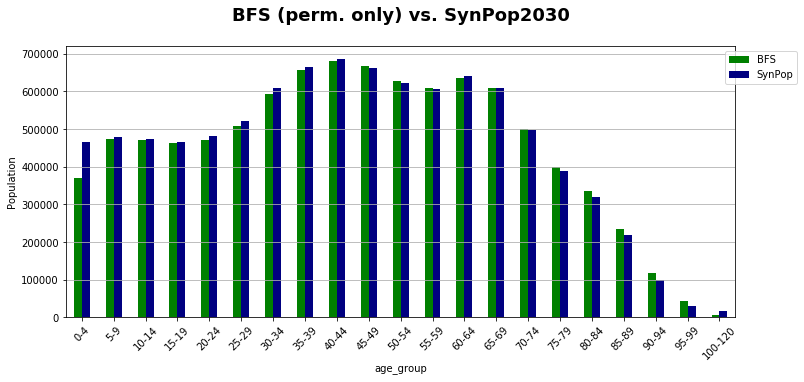

In [17]:
ax = pop_per_age_group.plot.bar(stacked=False, rot=45, color=['green', 'navy'], figsize=(12, 5))
_ = ax.legend(loc='best', bbox_to_anchor=(1.1, 1))
_ = ax.set_ylabel('Population')
ax.grid(axis='y')

title = 'BFS (perm. only) vs. SynPop{}'.format(YEAR)
_ = ax.set_title(title, pad=25, fontdict={'fontsize':18, 'fontweight':'bold'})

if SAVE_FIGURES:
    fig_file_name = '03-01_SynPop{}_vs_BFS_global_age_structure.{}'.format(YEAR, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI, format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)
    logging.info('Figure saved to file : {}'.format(fig_file_path))

## Export Notebook to HTML

In [18]:
### Write notebook to a html file
!jupyter nbconvert --to html 03_Age_Structure.ipynb

[NbConvertApp] Converting notebook 03_Age_Structure.ipynb to html
[NbConvertApp] Writing 327513 bytes to 03_Age_Structure.html
